In [8]:
import time
import heapq
import math
import random
import struct
from collections import defaultdict
from typing import List, Tuple, Dict, Set, Optional
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

Modern retrieval systems — from semantic search to recommendation engines to retrieval-augmented generation (RAG) — depend on finding the **k nearest neighbours** of a query vector inside a corpus of millions or billions of vectors.

Exact brute-force search is O(N·d) per query, which becomes prohibitively expensive at scale.

Three foundational techniques tackle this from complementary angles:

| Technique | Core Idea | Reduces |
|-----------|-----------|---------|
| **HNSW** (Hierarchical Navigable Small World) | Build a multi-layer navigable graph so search is ~O(log N) | **Number of distance computations** |
| **PQ** (Product Quantization) | Compress each vector into a short code; distances are approximated via lookup tables | **Memory footprint & distance cost** |
| **IVF** (Inverted File Index) | Partition the space with k-means; only search a few partitions | **Candidate set size** |

# 1) Data Loading

In [9]:
SEED = 42

def build_synthetic_dataset(
    num_samples: int = 50_000,
    model_dim: int = 128,
    num_queries: int = 500,
    num_clusters: int = 64,
    seed: int = SEED,
) -> Tuple[np.ndarray, np.ndarray]:
    """Create a clustered dataset plus held-out query vectors."""
    total = num_samples + num_queries

    # Generate clustered data using sklearn
    data, _ = make_blobs(
        n_samples=total,
        n_features=model_dim,
        centers=num_clusters,
        random_state=seed,
    )
    data = data.astype(np.float32)

    # Split data into database and queries
    database = data[:num_samples]
    queries = data[num_samples:]

    return database, queries

# Set parameters for a fast test run
NUM_SAMPLES = 10_000
MODEL_DIM = 128
NUM_QUERIES = 50

# Generate dataset
database, queries = build_synthetic_dataset(
    num_samples=NUM_SAMPLES,
    model_dim=MODEL_DIM,
    num_queries=NUM_QUERIES
)

print(f"Database shape: {database.shape}")
print(f"Queries shape: {queries.shape}")

Database shape: (10000, 128)
Queries shape: (50, 128)


In [10]:
# Brute-force

def exact_knn(
    queries: np.ndarray,
    database: np.ndarray,
    k: int = 10,
) -> np.ndarray:
    """Brute-force exact k-nearest-neighbour search using L2 distance."""
    # Expand squared L2: ||q - x||^2 = ||q||^2 + ||x||^2 - 2·q·x
    # (num_queries, model_dim) -> (num_queries, 1)
    q_sq = np.sum(queries ** 2, axis=1, keepdims=True)

    # (num_samples, model_dim) -> (1, num_samples)
    db_sq = np.sum(database ** 2, axis=1, keepdims=True).T

    # Compute distances
    # (num_queries, num_samples)
    dists = q_sq + db_sq - 2.0 * queries @ database.T

    # Partial sort to find top-k
    # (num_queries, num_samples) -> (num_queries, k)
    indices = np.argpartition(dists, kth=k, axis=1)[:, :k]

    # Sort the k candidates by true distance
    rows = np.arange(len(queries))[:, None]
    sorted_order = np.argsort(dists[rows, indices], axis=1)
    indices = indices[rows, sorted_order]

    return indices

K = 10
t0 = time.perf_counter()
gt_indices = exact_knn(queries, database, k=K)
brute_time = time.perf_counter() - t0

print(f"Exact KNN completed in {brute_time:.3f}s")
print(f"Ground truth shape: {gt_indices.shape} (num_queries, k)")

Exact KNN completed in 0.020s
Ground truth shape: (50, 10) (num_queries, k)


# 2) HNSW — Hierarchical Navigable Small World Graphs

The key insight behind HNSW is borrowed from **skip lists**: maintain multiple layers of a proximity graph at decreasing granularity. Upper layers have few nodes and large "jumps" (coarse navigation), while lower layers are dense (fine-grained search).

```text
Layer 2: o ─────────────────── o (very few nodes, long edges)
Layer 1: o ──── o ──── o ──── o ──── o (medium density)
Layer 0: o ─ o ─ o ─ o ─ o ─ o ─ o ─ o ─ o (all nodes, short edges)
```

A search starts at the **top layer** and greedily descends, narrowing the candidate set at each layer. This yields ~O(log N) distance computations on average.

### Key hyperparameters (from the paper)

| Parameter | Meaning | Typical |
|-----------|---------|---------|
| `M` | Max edges per node per layer | 16 |
| `ef_construction` | Beam width during insertion | 200 |
| `ef_search` | Beam width during query | 50–200 |
| `m_L` | Level generation factor: 1/ln(M) | ~0.36 for M=16 |


In [11]:
def l2_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Squared L2 distance between two vectors.

    Parameters
    ----------
    a : np.ndarray
        # (model_dim,)
    b : np.ndarray
        # (model_dim,)

    Returns
    -------
    float — ||a - b||^2
    """
    # (model_dim,)
    diff = a - b
    return float(np.dot(diff, diff))

In [12]:
class HNSW:
    """Hierarchical Navigable Small World graph for approximate KNN.

    The graph is stored as an adjacency list per layer:
    graph[layer][node_id] = set of neighbour ids
    Vectors are stored in a flat list indexed by insertion order.
    """
    def __init__(
        self,
        M: int = 16,
        ef_construction: int = 200,
        ef_search: int = 50,
        seed: int = SEED,
    ):
        # --- Hyperparameters (Section 4 of the paper) ---
        # M: max number of connections per element per layer.
        self.M = M
        # M_max0: max connections at layer 0 is typically 2*M (heuristic from paper).
        self.M_max0 = 2 * M
        # ef_construction: size of the dynamic candidate list during insertion.
        self.ef_construction = ef_construction
        # ef_search: beam width at query time (controls recall/speed trade-off).
        self.ef_search = ef_search
        # m_L: normalisation factor for random level generation = 1/ln(M).
        self.m_L = 1.0 / math.log(M)

        # --- Graph storage ---
        # vectors[i] stores the raw float32 vector for node i.
        self.vectors: List[np.ndarray] = []
        # graph[layer] = {node_id: set(neighbour_ids)}
        self.graph: Dict[int, Dict[int, Set[int]]] = defaultdict(
            lambda: defaultdict(set)
        )
        # entry_point: id of the current global entry point (top-layer node).
        self.entry_point: Optional[int] = None
        # max_layer: highest layer currently in the graph.
        self.max_layer: int = -1
        # node_layer[i] = the maximum layer that node i was assigned to.
        self.node_layer: List[int] = []

        self._rng = random.Random(seed)

    # ------------------------------------------------------------------
    # Level generation
    # ------------------------------------------------------------------
    def _random_level(self) -> int:
        """Draw a random layer for a new element.

        The distribution is:
            floor( -ln(uniform(0,1)) * m_L )
        This gives an exponentially decaying probability of higher layers,
        analogous to skip-list level assignment.
        """
        return int(-math.log(self._rng.random()) * self.m_L)

    # ------------------------------------------------------------------
    # Greedy search on a single layer
    # ------------------------------------------------------------------
    def _search_layer(
        self,
        query: np.ndarray,
        entry_points: List[int],
        ef: int,
        layer: int,
    ) -> List[Tuple[float, int]]:
        """Beam search (greedy BFS) on one layer of the graph.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)
        entry_points : List[int] — seed node ids
        ef : int — beam width (candidate list size)
        layer : int — which layer to search

        Returns
        -------
        List of (distance, node_id) — the ef closest nodes found.
        """
        # visited keeps track of all nodes we have evaluated.
        visited: Set[int] = set(entry_points)
        # candidates is a min-heap of (distance, id): nodes to explore.
        candidates = []
        # results is a max-heap of (-distance, id): best ef nodes found so far.
        results = []

        for ep in entry_points:
            d = l2_distance(query, self.vectors[ep])
            heapq.heappush(candidates, (d, ep))
            heapq.heappush(results, (-d, ep))

        while candidates:
            # Pick the closest unexplored candidate.
            cd, cid = heapq.heappop(candidates)
            # Furthest element in our result set.
            fd = -results[0][0]

            # If the closest candidate is further than our worst result, stop.
            # (Monotonicity: no future candidate can improve results.)
            if cd > fd:
                break

            # Expand neighbours of cid on this layer.
            for neighbour in self.graph[layer].get(cid, set()):
                if neighbour in visited:
                    continue
                visited.add(neighbour)

                nd = l2_distance(query, self.vectors[neighbour])
                fd = -results[0][0]

                # Only add if it improves the result set or we haven't filled ef.
                if nd < fd or len(results) < ef:
                    heapq.heappush(candidates, (nd, neighbour))
                    heapq.heappush(results, (-nd, neighbour))
                    # Trim results to ef.
                    if len(results) > ef:
                        heapq.heappop(results)

        # Convert max-heap to sorted list (ascending distance).
        out = [(-d, idx) for d, idx in results]
        out.sort()
        return out

    # ------------------------------------------------------------------
    # Select neighbours (simple version)
    # ------------------------------------------------------------------
    def _select_neighbours_simple(
        self,
        candidates: List[Tuple[float, int]],
        M: int,
    ) -> List[Tuple[float, int]]:
        """Return the M closest candidates.
        """
        candidates.sort()
        return candidates[:M]

    # ------------------------------------------------------------------
    # Insert
    # ------------------------------------------------------------------
    def insert(self, vector: np.ndarray) -> None:
        """Insert a single vector into the HNSW graph.

        This is Algorithm 1: INSERT.
        Steps:
        1. Assign a random level l to the new node.
        2. From the entry point, greedily descend layers > l to find the closest node (ef=1).
        3. From layer l down to 0, run SEARCH-LAYER with ef=ef_construction to find neighbours,
           then create bidirectional edges.

        Parameters
        ----------
        vector : np.ndarray
            # (model_dim,)
        """
        node_id = len(self.vectors)
        self.vectors.append(vector)

        # Assign random level.
        node_level = self._random_level()
        self.node_layer.append(node_level)

        # Handle first insertion.
        if self.entry_point is None:
            self.entry_point = node_id
            self.max_layer = node_level
            return

        # --- Phase 1: Greedy descent from top layer to node_level + 1 ---
        # Navigate with ef=1 (pure greedy) through layers above node_level.
        ep = [self.entry_point]
        for layer in range(self.max_layer, node_level, -1):
            results = self._search_layer(vector, ep, ef=1, layer=layer)
            # Use the single closest node as the entry point for the next layer.
            ep = [results[0][1]]

        # --- Phase 2: Insert into layers node_level down to 0 ---
        for layer in range(min(node_level, self.max_layer), -1, -1):
            results = self._search_layer(
                vector, ep, ef=self.ef_construction, layer=layer
            )

            # Decide how many connections to keep.
            M_layer = self.M_max0 if layer == 0 else self.M
            neighbours = self._select_neighbours_simple(results, M_layer)

            # Create bidirectional edges.
            for _, nid in neighbours:
                self.graph[layer][node_id].add(nid)
                self.graph[layer][nid].add(node_id)

                # Prune neighbour's connections if they exceed M_layer.
                if len(self.graph[layer][nid]) > M_layer:
                    # Re-rank nid's neighbours and keep the closest M_layer.
                    scored = [
                        (l2_distance(self.vectors[nid], self.vectors[nb]), nb)
                        for nb in self.graph[layer][nid]
                    ]
                    pruned = self._select_neighbours_simple(scored, M_layer)
                    self.graph[layer][nid] = {idx for _, idx in pruned}

            # Use the results as entry points for the next (lower) layer.
            ep = [r[1] for r in results]

        # Update global entry point if this node has a higher level.
        if node_level > self.max_layer:
            self.entry_point = node_id
            self.max_layer = node_level

    # ------------------------------------------------------------------
    # KNN Search
    # ------------------------------------------------------------------
    def search(
        self,
        query: np.ndarray,
        k: int = 10,
        ef: Optional[int] = None
    ) -> List[Tuple[float, int]]:
        """Find the k approximate nearest neighbours of a query.

        This is Algorithm 5: KNN-SEARCH.
        1. Greedily descend from the top layer to layer 1 (ef=1).
        2. At layer 0, run SEARCH-LAYER with ef=ef_search.
        3. Return the k closest from the result set.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)
        k : int
        ef : int | None — overrides self.ef_search if provided.

        Returns
        -------
        List of (distance, node_id), length k, sorted ascending.
        """
        if ef is None:
            ef = self.ef_search
        ef = max(ef, k)

        ep = [self.entry_point]

        # Greedy descent through upper layers.
        for layer in range(self.max_layer, 0, -1):
            results = self._search_layer(query, ep, ef=1, layer=layer)
            ep = [results[0][1]]

        # Full beam search on layer 0.
        results = self._search_layer(query, ep, ef=ef, layer=0)

        # Return top-k.
        results.sort()
        return results[:k]

    # ------------------------------------------------------------------
    # Batch search convenience
    # ------------------------------------------------------------------
    def batch_search(
        self,
        queries: np.ndarray,
        k: int = 10,
        ef: Optional[int] = None
    ) -> np.ndarray:
        """Search for multiple queries, returning an index array.

        Parameters
        ----------
        queries : np.ndarray
            # (num_queries, model_dim)

        Returns
        -------
        indices : np.ndarray
            # (num_queries, k)
        """
        # (num_queries, k)
        out = np.empty((len(queries), k), dtype=np.int64)
        for i, q in enumerate(queries):
            results = self.search(q, k=k, ef=ef)
            for j, (_, idx) in enumerate(results):
                out[i, j] = idx
        return out


In [13]:
# Build HNSW index
hnsw = HNSW(M=16, ef_construction=200, ef_search=64)

t0 = time.perf_counter()
for i in range(len(database)):
    hnsw.insert(database[i])
    if (i + 1) % 10000 == 0:
        print(f" Inserted {i + 1}/{len(database)}")
hnsw_build_time = time.perf_counter() - t0

print(f"HNSW build time: {hnsw_build_time:.2f}s")

# Query
t0 = time.perf_counter()
hnsw_indices = hnsw.batch_search(queries, k=K, ef=64)
hnsw_search_time = time.perf_counter() - t0
print(f"HNSW search time: {hnsw_search_time:.4f}s for {NUM_QUERIES} queries")

 Inserted 10000/10000
HNSW build time: 26.91s
HNSW search time: 0.0300s for 50 queries


# 3) Product Quantization (PQ)

PQ attacks the **memory** bottleneck. Storing 1 billion 128-d float32 vectors requires ~512 GB. PQ compresses each vector to a short code (e.g., 8 bytes) by splitting the vector into **sub-vectors** and independently quantizing each sub-vector with its own small codebook.

```text
Original vector (model_dim = 128, float32 → 512 bytes):
[ -------- sub0 -------- | -------- sub1 -------- | ... | sub7 ]
       16 dims → centroid id (1 byte)     16 dims → id (1 byte)

→ 1 byte PQ code:
[c0, c1, c2, c3, c4, c5, c6, c7] → 8 bytes total
```

At query time, distances are approximated using **Asymmetric Distance Computation (ADC)**: pre-compute a distance lookup table between the query sub-vectors and all centroids, then sum table lookups for each database code.

### Key Parameters

| Parameter | Meaning | Typical |
|-----------|---------|---------|
| `num_subspaces` (m) | Number of sub-vector splits | 8 |
| `num_centroids` (k*) | Centroids per sub-codebook | 256 (= 1 byte) |
| `sub_dim` | model_dim / num_subspaces | 16 |

In [14]:
class ProductQuantizer:
    """Product Quantization for vector compression and approximate search.

    The vector space R^model_dim is decomposed into `num_subspaces` orthogonal
    subspaces, each of dimension `sub_dim = model_dim // num_subspaces`.
    Each subspace has its own codebook of `num_centroids` centroids learned via k-means.
    A vector is encoded as the tuple of centroid indices.
    """
    def __init__(
        self,
        model_dim: int,
        num_subspaces: int = 8,
        num_centroids: int = 256,
        seed: int = SEED,
    ):
        assert model_dim % num_subspaces == 0, (
            "model_dim must be divisible by num_subspaces"
        )
        self.model_dim = model_dim
        self.num_subspaces = num_subspaces
        self.num_centroids = num_centroids
        # sub_dim: dimensionality of each sub-vector.
        self.sub_dim = model_dim // num_subspaces
        self.seed = seed

        # codebooks[m] has shape (num_centroids, sub_dim).
        self.codebooks: Optional[np.ndarray] = None
        # codes[i] has shape (num_subspaces,) — the PQ code for database vector i.
        self.codes: Optional[np.ndarray] = None

    # ------------------------------------------------------------------
    # Training: learn codebooks via k-means on each subspace
    # ------------------------------------------------------------------
    def train(self, data: np.ndarray) -> None:
        """Learn codebooks from training data.

        For each subspace m, extract the m-th sub-vector from all training points
        and run k-means to obtain `num_centroids` centroids.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)
        """
        num_samples = data.shape[0]
        # (num_subspaces, num_centroids, sub_dim)
        self.codebooks = np.zeros(
            (self.num_subspaces, self.num_centroids, self.sub_dim),
            dtype=np.float32,
        )

        for m in range(self.num_subspaces):
            # Extract the m-th sub-vector from all training points.
            start = m * self.sub_dim
            end = start + self.sub_dim
            # (num_samples, model_dim) -> (num_samples, sub_dim)
            sub_data = data[:, start:end]

            # Run k-means (using sklearn — k-means is not our focus).
            km = KMeans(
                n_clusters=self.num_centroids,
                random_state=self.seed,
                n_init=1,
                max_iter=20,
            )
            km.fit(sub_data)
            # Store centroids: (num_centroids, sub_dim)
            self.codebooks[m] = km.cluster_centers_.astype(np.float32)

        print(
            f"PQ trained: {self.num_subspaces} subspaces × "
            f"{self.num_centroids} centroids × {self.sub_dim}d"
        )

    # ------------------------------------------------------------------
    # Encoding: compress vectors to PQ codes
    # ------------------------------------------------------------------
    def encode(self, data: np.ndarray) -> np.ndarray:
        """Encode vectors into PQ codes by assigning each sub-vector to its nearest centroid.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)

        Returns
        -------
        codes : np.ndarray
            # (num_samples, num_subspaces)
            dtype=uint8
        """
        num_samples = data.shape[0]
        # (num_samples, num_subspaces)
        codes = np.zeros(
            (num_samples, self.num_subspaces),
            dtype=np.uint8
        )

        for m in range(self.num_subspaces):
            start = m * self.sub_dim
            end = start + self.sub_dim
            # (num_samples, sub_dim)
            sub_data = data[:, start:end]

            # Compute distances from each sub-vector to all centroids.
            # (num_samples, sub_dim) vs (num_centroids, sub_dim) -> (num_samples, num_centroids)
            cb = self.codebooks[m]
            dists = (
                np.sum(sub_data ** 2, axis=1, keepdims=True)
                + np.sum(cb ** 2, axis=1, keepdims=True).T
                - 2.0 * sub_data @ cb.T
            )

            # Assign to nearest centroid.
            # (num_samples, num_centroids) -> (num_samples,)
            codes[:, m] = np.argmin(dists, axis=1).astype(np.uint8)

        return codes

    # ------------------------------------------------------------------
    # Asymmetric Distance Computation (ADC)
    # ------------------------------------------------------------------
    def build_distance_table(self, query: np.ndarray) -> np.ndarray:
        """Pre-compute distances between query sub-vectors and all centroids.

        This is the core of ADC (Section 4.2 of the paper): instead of decoding
        each PQ code back to float32, we build a lookup table so that the distance
        to any code is a sum of table lookups.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)

        Returns
        -------
        table : np.ndarray
            # (num_subspaces, num_centroids)
            table[m, c] = ||query_m - codebook[m][c]||^2
        """
        # (num_subspaces, num_centroids)
        table = np.zeros(
            (self.num_subspaces, self.num_centroids),
            dtype=np.float32
        )

        for m in range(self.num_subspaces):
            start = m * self.sub_dim
            end = start + self.sub_dim
            # (sub_dim,)
            q_sub = query[start:end]
            # (num_centroids, sub_dim)
            cb = self.codebooks[m]
            # (num_centroids,) — squared L2 from query sub-vector to each centroid.
            table[m] = np.sum((cb - q_sub) ** 2, axis=1)

        return table

    def adc_distances(
        self,
        table: np.ndarray,
        codes: np.ndarray
    ) -> np.ndarray:
        """Compute approximate distances via ADC table lookups.

        For each database code, the approximate distance to the query is:
            d_approx(q, x) = Σ_m table[m, code[m]]
        This replaces the O(model_dim) dot-product with O(num_subspaces) table lookups
        — a massive speedup when model_dim >> num_subspaces.

        Parameters
        ----------
        table : np.ndarray
            # (num_subspaces, num_centroids)
        codes : np.ndarray
            # (num_samples, num_subspaces)

        Returns
        -------
        distances : np.ndarray
            # (num_samples,)
        """
        num_samples = codes.shape[0]
        # (num_samples,)
        distances = np.zeros(num_samples, dtype=np.float32)

        # Vectorised: for each subspace, index into the table.
        for m in range(self.num_subspaces):
            # codes[:, m] has shape (num_samples,) — centroid indices for subspace m.
            # table[m] has shape (num_centroids,).
            # Fancy indexing: (num_samples,)
            distances += table[m, codes[:, m]]

        return distances

    # ------------------------------------------------------------------
    # Full search pipeline
    # ------------------------------------------------------------------
    def search(
        self,
        query: np.ndarray,
        codes: np.ndarray,
        k: int = 10,
    ) -> np.ndarray:
        """Search for k approximate nearest neighbours using ADC.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)
        codes : np.ndarray
            # (num_samples, num_subspaces)
        k : int

        Returns
        -------
        indices : np.ndarray
            # (k,) — indices into the database
        """
        # (num_subspaces, num_centroids)
        table = self.build_distance_table(query)
        # (num_samples,)
        dists = self.adc_distances(table, codes)
        # (num_samples,) -> (k,)
        return np.argpartition(dists, k)[:k]

    def batch_search(
        self,
        queries: np.ndarray,
        codes: np.ndarray,
        k: int = 10,
    ) -> np.ndarray:
        """Batch search over multiple queries.

        Parameters
        ----------
        queries : np.ndarray
            # (num_queries, model_dim)
        codes : np.ndarray
            # (num_samples, num_subspaces)
        k : int

        Returns
        -------
        indices : np.ndarray
            # (num_queries, k)
        """
        # (num_queries, k)
        out = np.empty((len(queries), k), dtype=np.int64)
        for i, q in enumerate(queries):
            out[i] = self.search(q, codes, k=k)
        return out

    # ------------------------------------------------------------------
    # Memory footprint
    # ------------------------------------------------------------------
    def memory_bytes(self, num_samples: int) -> dict:
        """Estimate memory usage.

        Returns dict with codebook bytes, code bytes, and total.
        """
        codebook_bytes = (
            self.num_subspaces * self.num_centroids * self.sub_dim * 4
        )
        code_bytes = num_samples * self.num_subspaces  # uint8
        return {
            "codebooks": codebook_bytes,
            "codes": code_bytes,
            "total": codebook_bytes + code_bytes,
        }

In [15]:
pq = ProductQuantizer(
    model_dim=MODEL_DIM,
    num_subspaces=8,
    num_centroids=256
)

# Train codebooks on the database.
t0 = time.perf_counter()
pq.train(database)
pq_train_time = time.perf_counter() - t0
print(f"PQ training time: {pq_train_time:.2f}s")

# Encode the entire database.
t0 = time.perf_counter()
pq_codes = pq.encode(database)
pq_encode_time = time.perf_counter() - t0
print(f"PQ encode time: {pq_encode_time:.2f}s")
print(f"PQ codes shape: {pq_codes.shape} dtype: {pq_codes.dtype}")

# Memory comparison.
raw_bytes = NUM_SAMPLES * MODEL_DIM * 4
pq_mem = pq.memory_bytes(NUM_SAMPLES)
print(f"\nRaw database    : {raw_bytes / 1e6:.1f} MB")
print(f"PQ total        : {pq_mem['total'] / 1e6:.2f} MB")
print(f"Compression     : {raw_bytes / pq_mem['total']:.1f}×")

# Search.
t0 = time.perf_counter()
pq_indices = pq.batch_search(queries, pq_codes, k=K)
pq_search_time = time.perf_counter() - t0
print(f"\nPQ search time: {pq_search_time:.4f}s for {NUM_QUERIES} queries")

PQ trained: 8 subspaces × 256 centroids × 16d
PQ training time: 2.10s
PQ encode time: 0.06s
PQ codes shape: (10000, 8) dtype: uint8

Raw database    : 5.1 MB
PQ total        : 0.21 MB
Compression     : 24.3×

PQ search time: 0.0244s for 50 queries


# 4) IVF — Inverted File Index

IVF addresses **candidate set reduction**. Instead of comparing a query to every database vector, we first partition the space into `num_cells` Voronoi cells via k-means. At query time, we only search the `nprobe` closest cells.

```text
       ┌────────┐
query ──▶│ coarse │──▶ find nprobe closest cells ──▶ exhaustive search
       │quantizer│                                  within those cells only
       └────────┘
```

This reduces the number of distance computations from N to roughly `nprobe * (N / num_cells)`.

### Key Parameters

| Parameter | Meaning | Typical |
|-----------|---------|---------|
| `num_cells` | Number of Voronoi partitions | sqrt(N) to 4*sqrt(N) |
| `nprobe` | Cells to visit at query time | 1–64 |


In [16]:
class IVFIndex:
    """Inverted File Index for approximate nearest neighbour search.

    The index partitions the vector space into `num_cells` Voronoi cells using k-means.
    Each cell maintains an inverted list of (vector_id, vector) pairs.
    At query time, only the `nprobe` closest cells are searched exhaustively.

    Reference: Jégou et al., TPAMI 2011, Section 5.
    """
    def __init__(
        self,
        model_dim: int,
        num_cells: int = 256,
        nprobe: int = 8,
        seed: int = SEED,
    ):
        self.model_dim = model_dim
        self.num_cells = num_cells
        self.nprobe = nprobe
        self.seed = seed

        # centroids: (num_cells, model_dim) — Voronoi cell centres.
        self.centroids: Optional[np.ndarray] = None
        # inverted_lists[cell_id] = list of (vector_id, vector) tuples.
        self.inverted_lists: Dict[int, List[Tuple[int, np.ndarray]]] = (
            defaultdict(list)
        )

    # ------------------------------------------------------------------
    # Training: learn the coarse quantizer via k-means
    # ------------------------------------------------------------------
    def train(self, data: np.ndarray) -> None:
        """Learn Voronoi cell centroids from training data.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)
        """
        # Learn the coarse quantizer.
        km = KMeans(
            n_clusters=self.num_cells,
            random_state=self.seed,
            n_init=1,
            max_iter=20,
        )
        km.fit(data)

        # (num_cells, model_dim)
        self.centroids = km.cluster_centers_.astype(np.float32)

        print(f"IVF trained: {self.num_cells} cells")

    # ------------------------------------------------------------------
    # Assignment: add vectors to their Voronoi cells
    # ------------------------------------------------------------------
    def add(self, data: np.ndarray) -> None:
        """Assign each database vector to its nearest cell and store it.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)
        """
        # Compute distances to find the nearest centroid for each vector.
        # (num_samples, num_cells)
        dists = (
            np.sum(data ** 2, axis=1, keepdims=True)
            + np.sum(self.centroids ** 2, axis=1, keepdims=True).T
            - 2.0 * data @ self.centroids.T
        )

        # (num_samples,)
        assignments = np.argmin(dists, axis=1)

        # Populate inverted lists with vector indices and their data.
        for vec_id in range(len(data)):
            cell = int(assignments[vec_id])
            self.inverted_lists[cell].append((vec_id, data[vec_id]))

        sizes = [len(self.inverted_lists[c]) for c in range(self.num_cells)]
        print(
            f"IVF populated: avg {np.mean(sizes):.0f} vectors/cell, "
            f"max {np.max(sizes)}, min {np.min(sizes)}"
        )

    # ------------------------------------------------------------------
    # Search
    # ------------------------------------------------------------------
    def search(
        self,
        query: np.ndarray,
        k: int = 10,
        nprobe: Optional[int] = None,
    ) -> np.ndarray:
        """Find k approximate nearest neighbours by probing nprobe cells.

        Steps:
        1. Compute distances from the query to all cell centroids.
        2. Select the nprobe closest cells.
        3. Exhaustively compute distances to all vectors in those cells.
        4. Return the k closest.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)
        k : int
        nprobe : int | None

        Returns
        -------
        indices : np.ndarray
            # (k,) — database vector ids
        """
        if nprobe is None:
            nprobe = self.nprobe

        # Calculate distance from query to each centroid.
        # (num_cells,)
        cent_dists = np.sum(
            (self.centroids - query) ** 2, axis=1
        )

        # Select nprobe closest cells.
        # (nprobe,)
        probe_cells = np.argpartition(cent_dists, nprobe)[:nprobe]

        # Gather all candidate vectors from the selected cells.
        candidates = []
        for cell in probe_cells:
            candidates.extend(self.inverted_lists[int(cell)])

        if len(candidates) == 0:
            return np.array([], dtype=np.int64)

        # Exhaustively search within candidates.
        cand_ids = np.array([c[0] for c in candidates], dtype=np.int64)
        cand_vecs = np.array([c[1] for c in candidates], dtype=np.float32)

        # (num_candidates,)
        dists = np.sum((cand_vecs - query) ** 2, axis=1)

        # Find the actual number of candidates we can return.
        actual_k = min(k, len(dists))

        # Extract the local top-k distances and sort them.
        top_k_local = np.argpartition(dists, actual_k)[:actual_k]
        top_k_local = top_k_local[np.argsort(dists[top_k_local])]

        return cand_ids[top_k_local]

    def batch_search(
        self,
        queries: np.ndarray,
        k: int = 10,
        nprobe: Optional[int] = None,
    ) -> np.ndarray:
        """Batch search.

        Parameters
        ----------
        queries : np.ndarray
            # (num_queries, model_dim)

        Returns
        -------
        indices : np.ndarray
            # (num_queries, k)
        """
        # (num_queries, k)
        out = np.empty((len(queries), k), dtype=np.int64)

        for i, q in enumerate(queries):
            result = self.search(q, k=k, nprobe=nprobe)
            # Pad if fewer than k results were found.
            if len(result) < k:
                result = np.pad(
                    result, (0, k - len(result)), constant_values=-1
                )
            out[i] = result[:k]

        return out


In [17]:
# A common heuristic: num_cells ≈ sqrt(N)
num_cells = int(np.sqrt(NUM_SAMPLES))
print(f"Using {num_cells} cells (≈ sqrt({NUM_SAMPLES}))")

ivf = IVFIndex(model_dim=MODEL_DIM, num_cells=num_cells, nprobe=8)

t0 = time.perf_counter()
ivf.train(database)
ivf_train_time = time.perf_counter() - t0
print(f"IVF training time: {ivf_train_time:.2f}s")

t0 = time.perf_counter()
ivf.add(database)
ivf_add_time = time.perf_counter() - t0
print(f"IVF add time: {ivf_add_time:.2f}s")

t0 = time.perf_counter()
ivf_indices = ivf.batch_search(queries, k=K, nprobe=8)
ivf_search_time = time.perf_counter() - t0
print(f"IVF search time: {ivf_search_time:.4f}s for {NUM_QUERIES} queries")


Using 100 cells (≈ sqrt(10000))
IVF trained: 100 cells
IVF training time: 0.42s
IVF populated: avg 100 vectors/cell, max 158, min 8
IVF add time: 0.04s
IVF search time: 0.0486s for 50 queries


# 5) IVF + PQ — The Combined System

IVF and PQ are complementary:
- **IVF** reduces the number of candidates to scan.
- **PQ** compresses the candidates so distance computation is fast and memory-efficient.

In the combined **IVF-PQ** system (FAISS calls this `IndexIVFPQ`):
1. Train a coarse quantizer (k-means) to define Voronoi cells.
2. For each vector, compute its **residual** (vector minus cell centroid).
3. Train PQ codebooks on the residuals.
4. Store only PQ codes in the inverted lists (huge memory savings).
5. At query time, compute the query residual w.r.t. each probed cell centroid and use ADC on the stored codes.

### Why Residuals?
Subtracting the cell centroid removes the coarse structure. The residuals have smaller variance, so PQ can quantize them more accurately.

In [18]:
class IVFPQIndex:
    """Inverted File Index with Product Quantization on residuals.

    Combines coarse quantization (IVF) with fine quantization (PQ) of residual vectors
    for memory-efficient approximate search.

    Reference: Jégou et al., TPAMI 2011, Section 5.2 (IVFADC).
    """
    def __init__(
        self,
        model_dim: int,
        num_cells: int = 256,
        nprobe: int = 8,
        num_subspaces: int = 8,
        num_centroids: int = 256,
        seed: int = SEED,
    ):
        self.model_dim = model_dim
        self.num_cells = num_cells
        self.nprobe = nprobe
        self.seed = seed

        # PQ for residual compression.
        self.pq = ProductQuantizer(
            model_dim=model_dim,
            num_subspaces=num_subspaces,
            num_centroids=num_centroids,
            seed=seed,
        )

        # Coarse centroids: (num_cells, model_dim)
        self.centroids: Optional[np.ndarray] = None

        # inverted_lists[cell_id] = list of (vector_id, pq_code) tuples.
        # pq_code has shape (num_subspaces,) dtype=uint8.
        self.inverted_lists: Dict[int, List[Tuple[int, np.ndarray]]] = (
            defaultdict(list)
        )

    def train(self, data: np.ndarray) -> None:
        """Train the coarse quantizer and PQ codebooks on residuals.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)
        """
        # Train coarse quantizer.
        km = KMeans(
            n_clusters=self.num_cells,
            random_state=self.seed,
            n_init=1,
            max_iter=20,
        )
        km.fit(data)
        self.centroids = km.cluster_centers_.astype(np.float32)
        print(f"IVF-PQ coarse quantizer: {self.num_cells} cells")

        # Compute residuals for PQ training.
        # (num_samples, num_cells)
        dists = (
            np.sum(data ** 2, axis=1, keepdims=True)
            + np.sum(self.centroids ** 2, axis=1, keepdims=True).T
            - 2.0 * data @ self.centroids.T
        )

        # (num_samples,)
        assignments = np.argmin(dists, axis=1)

        # Compute the residual vector relative to the assigned centroid.
        # (num_samples, model_dim)
        residuals = data - self.centroids[assignments]

        # Train PQ on residuals.
        self.pq.train(residuals)

    def add(self, data: np.ndarray) -> None:
        """Assign vectors to cells and store their residual PQ codes.

        Parameters
        ----------
        data : np.ndarray
            # (num_samples, model_dim)
        """
        # Assign to cells based on closest centroid.
        # (num_samples, num_cells)
        dists = (
            np.sum(data ** 2, axis=1, keepdims=True)
            + np.sum(self.centroids ** 2, axis=1, keepdims=True).T
            - 2.0 * data @ self.centroids.T
        )

        # (num_samples,)
        assignments = np.argmin(dists, axis=1)

        # Extract the residuals.
        # (num_samples, model_dim)
        residuals = data - self.centroids[assignments]

        # Encode the residuals.
        # (num_samples, num_subspaces)
        codes = self.pq.encode(residuals)

        # Store the compressed code inside the respective cell's inverted list.
        for vec_id in range(len(data)):
            cell = int(assignments[vec_id])
            self.inverted_lists[cell].append((vec_id, codes[vec_id]))

        sizes = [len(self.inverted_lists[c]) for c in range(self.num_cells)]
        print(
            f"IVF-PQ populated: avg {np.mean(sizes):.0f} vectors/cell"
        )

    def search(
        self,
        query: np.ndarray,
        k: int = 10,
        nprobe: Optional[int] = None,
    ) -> np.ndarray:
        """Search using IVF for candidate selection and PQ-ADC for scoring.

        For each probed cell:
        1. Compute query residual = query - cell_centroid.
        2. Build ADC distance table from this residual.
        3. Score all PQ codes in the cell via table lookups.

        Parameters
        ----------
        query : np.ndarray
            # (model_dim,)

        Returns
        -------
        indices : np.ndarray
            # (k,)
        """
        if nprobe is None:
            nprobe = self.nprobe

        # Find nprobe closest cells.
        # (num_cells,)
        cent_dists = np.sum((self.centroids - query) ** 2, axis=1)
        # (nprobe,)
        probe_cells = np.argpartition(cent_dists, nprobe)[:nprobe]

        # Collect (vector_id, approximate_distance) across all probed cells.
        all_ids = []
        all_dists = []

        for cell in probe_cells:
            entries = self.inverted_lists[int(cell)]
            if not entries:
                continue

            # Query residual w.r.t. this cell's centroid.
            # (model_dim,)
            q_residual = query - self.centroids[int(cell)]

            # Build ADC table from the residual.
            # (num_subspaces, num_centroids)
            table = self.pq.build_distance_table(q_residual)

            # Score each code in this cell.
            ids = [e[0] for e in entries]
            codes = np.array([e[1] for e in entries], dtype=np.uint8)

            # Calculate approximated distances.
            # (num_entries,)
            dists = self.pq.adc_distances(table, codes)

            all_ids.extend(ids)
            all_dists.extend(dists.tolist())

        if not all_ids:
            return np.array([], dtype=np.int64)

        all_ids = np.array(all_ids, dtype=np.int64)
        all_dists = np.array(all_dists, dtype=np.float32)

        # Narrow down the results across all combined cell returns.
        actual_k = min(k, len(all_ids))
        top_k = np.argpartition(all_dists, actual_k)[:actual_k]
        top_k = top_k[np.argsort(all_dists[top_k])]

        return all_ids[top_k]

    def batch_search(
        self,
        queries: np.ndarray,
        k: int = 10,
        nprobe: Optional[int] = None,
    ) -> np.ndarray:
        """Batch search.

        Parameters
        ----------
        queries : np.ndarray
            # (num_queries, model_dim)

        Returns
        -------
        indices : np.ndarray
            # (num_queries, k)
        """
        # (num_queries, k)
        out = np.empty((len(queries), k), dtype=np.int64)
        for i, q in enumerate(queries):
            result = self.search(q, k=k, nprobe=nprobe)
            if len(result) < k:
                result = np.pad(
                    result, (0, k - len(result)), constant_values=-1
                )
            out[i] = result[:k]
        return out

    def memory_bytes(self, num_samples: int) -> dict:
        """Estimate memory: centroids + PQ codebooks + PQ codes (no raw vectors)."""
        centroid_bytes = self.num_cells * self.model_dim * 4
        pq_mem = self.pq.memory_bytes(num_samples)
        return {
            "centroids": centroid_bytes,
            "pq_codebooks": pq_mem["codebooks"],
            "pq_codes": pq_mem["codes"],
            "total": centroid_bytes + pq_mem["total"],
        }


In [19]:
ivfpq = IVFPQIndex(
    model_dim=MODEL_DIM,
    num_cells=num_cells,
    nprobe=8,
    num_subspaces=8,
    num_centroids=256,
)

t0 = time.perf_counter()
ivfpq.train(database)
ivfpq_train_time = time.perf_counter() - t0
print(f"IVF-PQ training time: {ivfpq_train_time:.2f}s")

t0 = time.perf_counter()
ivfpq.add(database)
ivfpq_add_time = time.perf_counter() - t0
print(f"IVF-PQ add time: {ivfpq_add_time:.2f}s")

t0 = time.perf_counter()
ivfpq_indices = ivfpq.batch_search(queries, k=K, nprobe=8)
ivfpq_search_time = time.perf_counter() - t0
print(f"IVF-PQ search time: {ivfpq_search_time:.4f}s for {NUM_QUERIES} queries")

# Memory comparison.
ivfpq_mem = ivfpq.memory_bytes(NUM_SAMPLES)
print(f"\nRaw database : {raw_bytes / 1e6:.1f} MB")
print(f"IVF-PQ total : {ivfpq_mem['total'] / 1e6:.2f} MB")
print(f"Compression : {raw_bytes / ivfpq_mem['total']:.1f}×")


IVF-PQ coarse quantizer: 100 cells
PQ trained: 8 subspaces × 256 centroids × 16d
IVF-PQ training time: 2.54s
IVF-PQ populated: avg 100 vectors/cell
IVF-PQ add time: 0.11s
IVF-PQ search time: 0.1467s for 50 queries

Raw database : 5.1 MB
IVF-PQ total : 0.26 MB
Compression : 19.5×


# 6) Evaluation

Evaluate ANN indices along three axes:

| Metric | Definition | Why It Matters |
|--------|-----------|----------------|
| **Recall@k** | Fraction of true k-NN found in the approximate result | Retrieval quality |
| **QPS** | Queries per second | Throughput |
| **Memory** | Index size in bytes | Scalability |

**Recall@k**
For a single query:
$$\text{Recall@k} = \frac{|\text{ANN result} \cap \text{True KNN}|}{k}$$
We report the **mean** over all queries.

**Speed–Recall Trade-off**
Each method has a knob that trades recall for speed:
- **HNSW**: `ef_search` (beam width)
- **PQ**: no direct knob (recall depends on codebook quality)
- **IVF**: `nprobe` (number of cells probed)
- **IVF-PQ**: `nprobe`

## 6.1) Recall@k Computation

In [20]:
def recall_at_k(
    predicted: np.ndarray,
    ground_truth: np.ndarray,
) -> float:
    """Compute mean Recall@k.

    Parameters
    ----------
    predicted : np.ndarray
        # (num_queries, k)
    ground_truth : np.ndarray
        # (num_queries, k)

    Returns
    -------
    float — mean recall across all queries, in [0, 1].
    """
    num_queries = predicted.shape[0]
    k = ground_truth.shape[1]
    total_recall = 0.0

    for i in range(num_queries):
        gt_set = set(ground_truth[i].tolist())
        pred_set = set(predicted[i].tolist())

        # Discard padding (-1 values).
        pred_set.discard(-1)
        total_recall += len(gt_set & pred_set) / k

    return total_recall / num_queries


## 6.2) Compute Recall & QPS for All Methods

In [21]:
results = {}

# Brute Force (baseline)
results["Brute Force"] = {
    "recall": 1.0,
    "qps": NUM_QUERIES / brute_time,
    "search_time": brute_time,
    "memory_mb": raw_bytes / 1e6,
}

# HNSW
r = recall_at_k(hnsw_indices, gt_indices)
results["HNSW (ef=64)"] = {
    "recall": r,
    "qps": NUM_QUERIES / hnsw_search_time,
    "search_time": hnsw_search_time,
    "memory_mb": None,  # Graph memory is complex to estimate
}

# PQ
r = recall_at_k(pq_indices, gt_indices)
results["PQ (m=8)"] = {
    "recall": r,
    "qps": NUM_QUERIES / pq_search_time,
    "search_time": pq_search_time,
    "memory_mb": pq_mem["total"] / 1e6,
}

# IVF
r = recall_at_k(ivf_indices, gt_indices)
results["IVF (nprobe=8)"] = {
    "recall": r,
    "qps": NUM_QUERIES / ivf_search_time,
    "search_time": ivf_search_time,
    "memory_mb": raw_bytes / 1e6,  # IVF alone stores raw vectors
}

# IVF-PQ
r = recall_at_k(ivfpq_indices, gt_indices)
results["IVF-PQ (nprobe=8)"] = {
    "recall": r,
    "qps": NUM_QUERIES / ivfpq_search_time,
    "search_time": ivfpq_search_time,
    "memory_mb": ivfpq_mem["total"] / 1e6,
}

print(f"{'Method':<25} {'Recall@10':>10} {'QPS':>10} {'Memory (MB)':>12}")
print("-" * 60)
for name, m in results.items():
    mem_str = f"{m['memory_mb']:.2f}" if m["memory_mb"] else "N/A"
    print(f"{name:<25} {m['recall']:>10.4f} {m['qps']:>10.1f} {mem_str:>12}")


Method                     Recall@10        QPS  Memory (MB)
------------------------------------------------------------
Brute Force                   1.0000     2535.5         5.12
HNSW (ef=64)                  0.6080     1665.2          N/A
PQ (m=8)                      0.1760     2050.0         0.21
IVF (nprobe=8)                1.0000     1029.8         5.12
IVF-PQ (nprobe=8)             0.3280      340.9         0.26


## 6.3) Recall vs. nprobe Sweep (IVF and IVF-PQ)

One of the most important practical plots: how does recall scale with nprobe?

In [22]:
nprobe_values = [1, 2, 4, 8, 16, 32, 64, 128]
# Ensure we do not probe more cells than exist in the index.
nprobe_values = [np_val for np_val in nprobe_values if np_val <= ivf.num_cells]

ivf_recalls = []
ivfpq_recalls = []
ivf_qps_list = []
ivfpq_qps_list = []

for np_val in nprobe_values:
    # IVF sweep
    t0 = time.perf_counter()
    idx = ivf.batch_search(queries, k=K, nprobe=np_val)
    dt = time.perf_counter() - t0
    ivf_recalls.append(recall_at_k(idx, gt_indices))
    ivf_qps_list.append(NUM_QUERIES / dt)

    # IVF-PQ sweep
    t0 = time.perf_counter()
    idx = ivfpq.batch_search(queries, k=K, nprobe=np_val)
    dt = time.perf_counter() - t0
    ivfpq_recalls.append(recall_at_k(idx, gt_indices))
    ivfpq_qps_list.append(NUM_QUERIES / dt)


## 6.4) Recall vs. ef_search Sweep (HNSW)

In [23]:
ef_values = [10, 20, 40, 64, 100, 200, 400]

hnsw_recalls = []
hnsw_qps_list = []

for ef in ef_values:
    t0 = time.perf_counter()
    idx = hnsw.batch_search(queries, k=K, ef=ef)
    dt = time.perf_counter() - t0
    hnsw_recalls.append(recall_at_k(idx, gt_indices))
    hnsw_qps_list.append(NUM_QUERIES / dt)


## 6.6) Visualization

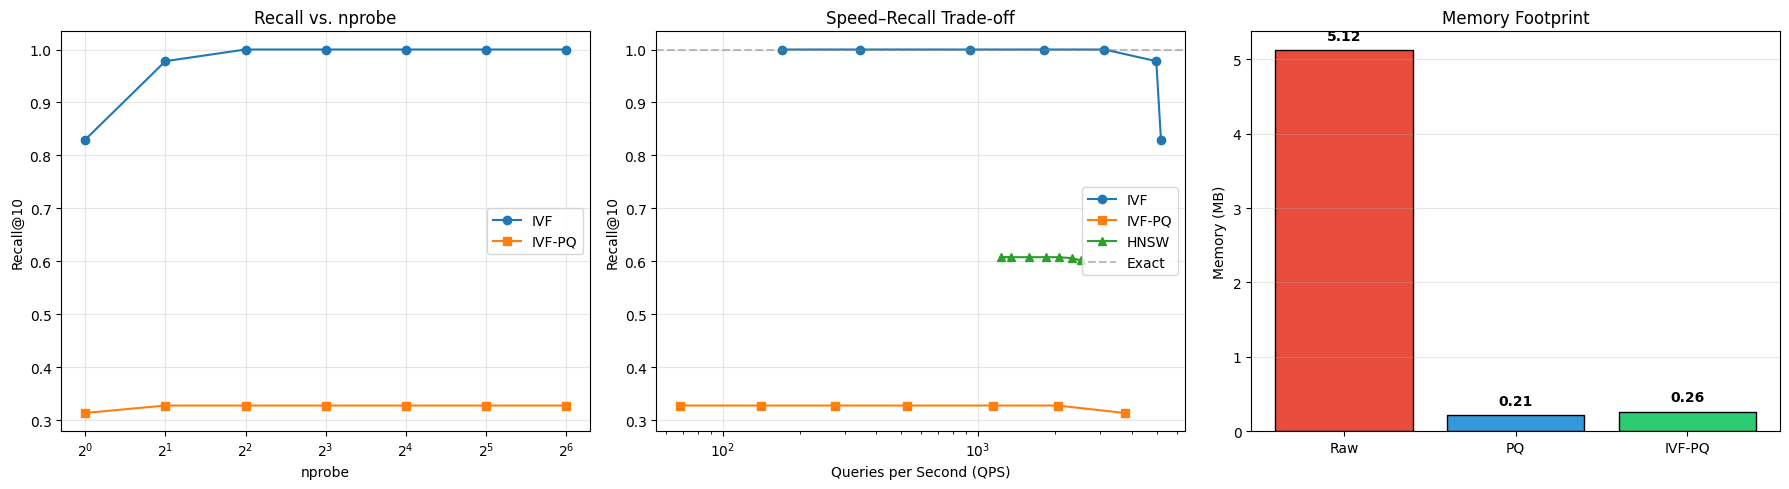

Figure saved to ann_evaluation.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Recall vs nprobe / ef ---
ax = axes[0]
ax.plot(nprobe_values, ivf_recalls, "o-", label="IVF")
ax.plot(nprobe_values, ivfpq_recalls, "s-", label="IVF-PQ")
ax.set_xlabel("nprobe")
ax.set_ylabel("Recall@10")
ax.set_title("Recall vs. nprobe")
ax.set_xscale("log", base=2)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Recall vs QPS (speed–accuracy trade-off) ---
ax = axes[1]
ax.plot(ivf_qps_list, ivf_recalls, "o-", label="IVF")
ax.plot(ivfpq_qps_list, ivfpq_recalls, "s-", label="IVF-PQ")
ax.plot(hnsw_qps_list, hnsw_recalls, "^-", label="HNSW")

# Add brute force reference point.
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="Exact")
ax.set_xlabel("Queries per Second (QPS)")
ax.set_ylabel("Recall@10")
ax.set_title("Speed–Recall Trade-off")
ax.set_xscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Memory comparison ---
ax = axes[2]
methods = ["Raw", "PQ", "IVF-PQ"]
mem_vals = [
    raw_bytes / 1e6,
    pq_mem["total"] / 1e6,
    ivfpq_mem["total"] / 1e6,
]
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.bar(methods, mem_vals, color=colors, edgecolor="black")

ax.set_ylabel("Memory (MB)")
ax.set_title("Memory Footprint")
ax.grid(True, alpha=0.3, axis="y")

# Add value labels on bars.
for bar, val in zip(bars, mem_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("ann_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to ann_evaluation.png")


## 6.5) Recall Distribution Per Query

Not all queries are equally easy. Let's look at the distribution of per-query recall values to understand variance.

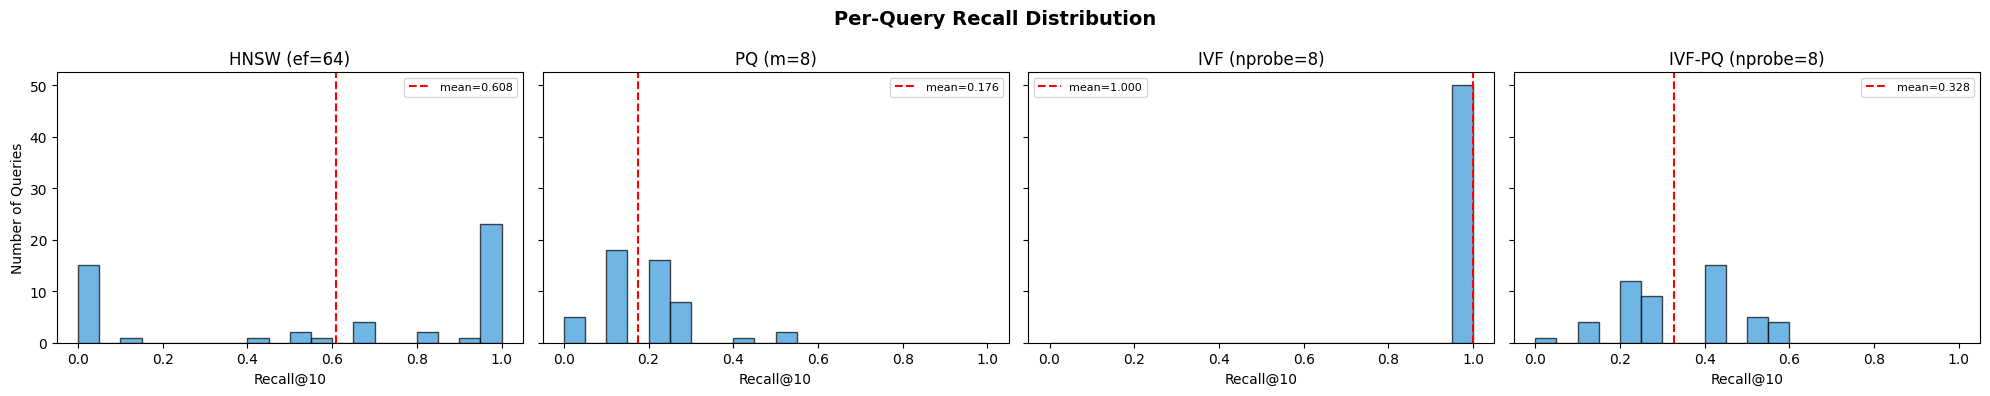

In [25]:
def per_query_recall(predicted: np.ndarray, ground_truth: np.ndarray) -> np.ndarray:
    """Compute recall for each individual query.

    Parameters
    ----------
    predicted : np.ndarray
        # (num_queries, k)
    ground_truth : np.ndarray
        # (num_queries, k)

    Returns
    -------
    recalls : np.ndarray
        # (num_queries,)
    """
    k = ground_truth.shape[1]
    recalls = np.zeros(len(predicted))

    for i in range(len(predicted)):
        gt_set = set(ground_truth[i].tolist())
        pred_set = set(predicted[i].tolist())
        pred_set.discard(-1)
        recalls[i] = len(gt_set & pred_set) / k

    return recalls

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

method_data = [
    ("HNSW (ef=64)", hnsw_indices),
    ("PQ (m=8)", pq_indices),
    ("IVF (nprobe=8)", ivf_indices),
    ("IVF-PQ (nprobe=8)", ivfpq_indices),
]

for ax, (name, pred) in zip(axes, method_data):
    recalls = per_query_recall(pred, gt_indices)

    ax.hist(recalls, bins=20, range=(0, 1), color="#3498db", edgecolor="black", alpha=0.7)
    ax.axvline(recalls.mean(), color="red", linestyle="--", label=f"mean={recalls.mean():.3f}")

    ax.set_title(name)
    ax.set_xlabel("Recall@10")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Number of Queries")
plt.suptitle("Per-Query Recall Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# Summary


| Method | Recall@10 | QPS | Memory | Key Insight |
|--------|-----------|-----|--------|-------------|
| Brute Force | 1.000 | Low | Full | Gold standard |
| HNSW | High | Medium | Graph overhead | Best recall, but graph is in-memory |
| PQ | Moderate | Medium | Very low | Best compression, trades recall |
| IVF | High | High | Full | Fast but no compression |
| IVF-PQ | Moderate–High | Highest | Very low | Best overall balance |

**When to Use What**
- **HNSW**: When you need **maximum recall** and can afford memory for the graph. Excellent for datasets up to ~10M vectors in RAM. Used in Pinecone, Qdrant, Weaviate.
- **PQ**: When **memory is the bottleneck** (e.g., 1B+ vectors). Accepts some recall degradation for 32–64× compression. Used as a building block inside FAISS.
- **IVF**: When the dataset is structured (clustered) and you want **fast candidate pruning**. Usually combined with PQ for the full pipeline.
- **IVF-PQ**: The **workhorse of large-scale search**. Powers FAISS's most-used index types. Best when you need to serve 100M–1B vectors with bounded memory.